# PTO simulation evaluation

This notebook evaluates Predict-Then-Optimise on the simplified thesis simulation panel. The simulation DGP is

```text
x_t -> p_{t+1} -> c_{t+1}
```

with

```text
p_{t+1} = sigmoid(gamma_0 + x_t' gamma)
```

and

```text
c_{t+1} ~ (1 - p_{t+1}) N(mu_n, sigma_n^2) + p_{t+1} N(mu_s, sigma_s^2).
```

The PTO models observe only macro covariates `x_t`. They learn a predicted mixture weight `p_hat_{t+1}` through the implied conditional mean charge-off. The known simulation probability and temporary realised regime are used for evaluation only, not as supervised training targets.


## 1. Imports and setup

The sigmoid linear model and sigmoid-output MLP are implemented directly in NumPy. This keeps the PTO objective explicit: minimise squared error between realised charge-offs and the model-implied conditional mean of the Gaussian mixture.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

if "seaborn-v0_8-whitegrid" in plt.style.available:
    plt.style.use("seaborn-v0_8-whitegrid")
elif "seaborn-whitegrid" in plt.style.available:
    plt.style.use("seaborn-whitegrid")
else:
    plt.style.use("default")

pd.set_option("display.max_columns", 120)
warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED = 42
rng_global = np.random.default_rng(SEED)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "models" / "src").exists() and (candidate / "models" / "simulation" / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Set REPO_ROOT manually in this cell.")


REPO_ROOT = find_repo_root()
MODELS_SRC = REPO_ROOT / "models" / "src"
if str(MODELS_SRC) not in sys.path:
    sys.path.insert(0, str(MODELS_SRC))

from capital_allocation_utils import CapitalConfig, optimise_alpha_from_p, realised_utility

print(f"Repo root: {REPO_ROOT}")


Repo root: /Users/hannahokeeffe/Documents/Imperial/DFL_New


## 2. Load the aligned synthetic panel

`simulated_variables.ipynb` stores rows in predictor-target aligned form: the macro covariates are the features observed at time `t`, while `true_stress_probability`, `charge_off_rate`, and `oracle_alpha` are the corresponding next-quarter simulation targets. This notebook does not apply `.shift()` because doing so would introduce an extra lag.


In [2]:
simulation_csv = REPO_ROOT / "models" / "simulation" / "data" / "simulated_variables.csv"
df = pd.read_csv(simulation_csv)

required_cols = [
    "time",
    "activity",
    "labour_market_stress",
    "financial_conditions",
    "true_stress_probability",
    "stress_regime",
    "charge_off_rate",
    "oracle_alpha",
]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f"Missing required simulated panel columns: {missing}")

feature_cols = ["activity", "labour_market_stress", "financial_conditions"]
df["feature_time"] = pd.to_datetime(df["time"])
df["target_time"] = df["feature_time"] + pd.DateOffset(months=3)
df = df.sort_values("feature_time").reset_index(drop=True)

for col in feature_cols + ["true_stress_probability", "charge_off_rate", "oracle_alpha"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["stress_regime"] = df["stress_regime"].astype(int)

if "oracle_utility" not in df.columns:
    cap_tmp = CapitalConfig(lgd=0.45, leverage=10.0)
    df["oracle_utility"] = [
        realised_utility(float(alpha), float(c), cap_tmp)
        for alpha, c in zip(df["oracle_alpha"], df["charge_off_rate"])
    ]

df = df.dropna(subset=feature_cols + ["true_stress_probability", "charge_off_rate", "oracle_alpha", "oracle_utility"]).reset_index(drop=True)

print(f"Loaded {len(df)} aligned observations from {simulation_csv.relative_to(REPO_ROOT)}")
print(f"Features: {feature_cols}")
print("Alignment check: no shift is applied by this notebook.")
display(df[["feature_time", "target_time", "true_stress_probability", "charge_off_rate", "oracle_alpha"]].head(8))
display(df[["true_stress_probability", "stress_regime", "charge_off_rate", "oracle_alpha", "oracle_utility"]].describe().T)


Loaded 500 aligned observations from models/simulation/data/simulated_variables.csv
Features: ['activity', 'labour_market_stress', 'financial_conditions']
Alignment check: no shift is applied by this notebook.


,feature_time,target_time,true_stress_probability,charge_off_rate,oracle_alpha
0,2000-01-01,2000-04-01,0.148047,0.009317,0.496157
1,2000-04-01,2000-07-01,0.189568,0.020767,0.392315
2,2000-07-01,2000-10-01,0.391229,0.010681,0.475773
3,2000-10-01,2001-01-01,0.381769,0.016926,0.414426
4,2001-01-01,2001-04-01,0.172237,0.005587,0.573180
5,2001-04-01,2001-07-01,0.170441,-0.003109,1.000000
6,2001-07-01,2001-10-01,0.080601,0.003798,0.626406
7,2001-10-01,2002-01-01,0.190727,0.011274,0.467904


,count,mean,std,min,25%,50%,75%,max
true_stress_probability,500.0,0.250776,0.241720,0.000128,0.050501,0.169149,0.391381,0.982286
stress_regime,500.0,0.254000,0.435734,0.000000,0.000000,0.000000,1.000000,1.000000
charge_off_rate,500.0,0.008489,0.006252,-0.006227,0.004265,0.007842,0.011296,0.033445
oracle_alpha,500.0,0.563503,0.155526,0.354918,0.467626,0.522420,0.610963,1.000000
oracle_utility,500.0,1.242108,0.101853,1.058757,1.180992,1.220244,1.279426,1.562273


## 3. PTO model definitions

Both PTO models output a probability in `(0, 1)`, interpreted as the predicted stress-mixture weight. The implied conditional mean charge-off is

```text
mu_hat_c = (1 - p_hat) * mu_normal + p_hat * mu_stress.
```

Training minimises mean squared error between this implied mean and the realised charge-off rate. The models are not trained on `true_stress_probability` or `stress_regime`.


In [3]:
@dataclass
class TrainConfig:
    linear_epochs: int = 450
    mlp_epochs: int = 650
    lr: float = 0.03
    beta1: float = 0.9
    beta2: float = 0.999
    eps: float = 1e-8
    hidden_dim: int = 8
    seed: int = 42


cap_cfg = CapitalConfig(lgd=0.45, leverage=10.0)
train_cfg = TrainConfig()
mu_normal = cap_cfg.mu_normal
mu_stress = cap_cfg.mu_stress
mixture_spread = mu_stress - mu_normal
PROB_EPS = 1e-6


def bounded_sigmoid(z):
    return PROB_EPS + (1.0 - 2.0 * PROB_EPS) * expit(z)


def mixture_mean_from_probability(p):
    p = np.asarray(p, dtype=float)
    return (1.0 - p) * mu_normal + p * mu_stress


def init_linear(n_features, rng):
    return {
        "w": rng.normal(0.0, 0.05, size=n_features),
        "b": np.array(0.0),
    }


def predict_linear(params, x):
    return bounded_sigmoid(x @ params["w"] + params["b"])


def train_linear(x, y, params=None, cfg=train_cfg, rng=None):
    rng = np.random.default_rng(cfg.seed) if rng is None else rng
    params = init_linear(x.shape[1], rng) if params is None else {k: np.array(v, copy=True) for k, v in params.items()}
    m = {"w": np.zeros_like(params["w"]), "b": np.array(0.0)}
    v = {"w": np.zeros_like(params["w"]), "b": np.array(0.0)}
    n = len(y)

    for step in range(1, cfg.linear_epochs + 1):
        p = predict_linear(params, x)
        mu_hat = mixture_mean_from_probability(p)
        dloss_dz = (2.0 / n) * (mu_hat - y) * mixture_spread * p * (1.0 - p)
        grads = {
            "w": x.T @ dloss_dz,
            "b": np.array(dloss_dz.sum()),
        }
        for key in params:
            m[key] = cfg.beta1 * m[key] + (1.0 - cfg.beta1) * grads[key]
            v[key] = cfg.beta2 * v[key] + (1.0 - cfg.beta2) * np.square(grads[key])
            m_hat = m[key] / (1.0 - cfg.beta1 ** step)
            v_hat = v[key] / (1.0 - cfg.beta2 ** step)
            params[key] -= cfg.lr * m_hat / (np.sqrt(v_hat) + cfg.eps)
    return params


def init_mlp(n_features, hidden_dim, rng):
    return {
        "W1": rng.normal(0.0, np.sqrt(1.0 / n_features), size=(n_features, hidden_dim)),
        "b1": np.zeros(hidden_dim),
        "W2": rng.normal(0.0, np.sqrt(1.0 / hidden_dim), size=(hidden_dim,)),
        "b2": np.array(0.0),
    }


def predict_mlp(params, x):
    hidden_pre = x @ params["W1"] + params["b1"]
    hidden = np.tanh(hidden_pre)
    z = hidden @ params["W2"] + params["b2"]
    return bounded_sigmoid(z)


def train_mlp(x, y, params=None, cfg=train_cfg, rng=None):
    rng = np.random.default_rng(cfg.seed + 1) if rng is None else rng
    params = init_mlp(x.shape[1], cfg.hidden_dim, rng) if params is None else {k: np.array(v, copy=True) for k, v in params.items()}
    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(v) for k, v in params.items()}
    n = len(y)

    for step in range(1, cfg.mlp_epochs + 1):
        hidden_pre = x @ params["W1"] + params["b1"]
        hidden = np.tanh(hidden_pre)
        z = hidden @ params["W2"] + params["b2"]
        p = expit(z)
        mu_hat = mixture_mean_from_probability(p)

        dloss_dz = (2.0 / n) * (mu_hat - y) * mixture_spread * p * (1.0 - p)
        grads = {
            "W2": hidden.T @ dloss_dz,
            "b2": np.array(dloss_dz.sum()),
        }
        dhidden = dloss_dz[:, None] * params["W2"][None, :]
        dhidden_pre = dhidden * (1.0 - np.square(hidden))
        grads["W1"] = x.T @ dhidden_pre
        grads["b1"] = dhidden_pre.sum(axis=0)

        for key in params:
            m[key] = cfg.beta1 * m[key] + (1.0 - cfg.beta1) * grads[key]
            v[key] = cfg.beta2 * v[key] + (1.0 - cfg.beta2) * np.square(grads[key])
            m_hat = m[key] / (1.0 - cfg.beta1 ** step)
            v_hat = v[key] / (1.0 - cfg.beta2 ** step)
            params[key] -= cfg.lr * m_hat / (np.sqrt(v_hat) + cfg.eps)
    return params


def model_predict(model_name, params, x):
    if model_name == "pto_linear_sigmoid":
        return predict_linear(params, x)
    if model_name == "pto_mlp_sigmoid":
        return predict_mlp(params, x)
    raise ValueError(f"Unknown model: {model_name}")


## 4. Expanding-window evaluation

At each test date, the scaler is fitted only on the current training window. The model is trained on all observations available up to the previous row, predicts the next held-out observation, and then the window expands by one observation.


In [4]:
def choose_initial_window(data, min_train=250, test_frac=0.35):
    proposed = int(np.floor(len(data) * (1.0 - test_frac)))
    initial = max(min_train, min(proposed, len(data) - 80))
    test = data.iloc[initial:]
    if test["stress_regime"].sum() < 10 and initial > min_train:
        initial = min_train
    return initial


initial_train_window = choose_initial_window(df)
train_part = df.iloc[:initial_train_window]
test_part = df.iloc[initial_train_window:]

print(f"Initial train observations: {len(train_part)}")
print(f"Test observations: {len(test_part)}")
print(f"Train stress share: {train_part['stress_regime'].mean():.3f}")
print(f"Test stress share: {test_part['stress_regime'].mean():.3f}")
print(f"Test stress count: {int(test_part['stress_regime'].sum())}")


def evaluate_one_step(model_name, params, scaler, test_row):
    x_test = scaler.transform(test_row[feature_cols])
    p_hat = float(model_predict(model_name, params, x_test)[0])
    mu_hat = float(mixture_mean_from_probability(p_hat))
    alpha_hat = float(optimise_alpha_from_p(p_hat, cap_cfg))

    realised_c = float(test_row["charge_off_rate"].iloc[0])
    oracle_alpha = float(test_row["oracle_alpha"].iloc[0])
    predicted_utility = realised_utility(alpha_hat, realised_c, cap_cfg)
    oracle_utility = float(test_row["oracle_utility"].iloc[0])
    regret = oracle_utility - predicted_utility

    true_p = float(test_row["true_stress_probability"].iloc[0])
    true_mu = float(mixture_mean_from_probability(true_p))

    return {
        "feature_time": test_row["feature_time"].iloc[0],
        "time": test_row["target_time"].iloc[0],
        "model": model_name,
        "train_size": int(test_row.index[0]),
        "true_stress_probability": true_p,
        "predicted_stress_probability": p_hat,
        "stress_regime": int(test_row["stress_regime"].iloc[0]),
        "true_conditional_mean_charge_off": true_mu,
        "predicted_mean_charge_off": mu_hat,
        "realised_charge_off_rate": realised_c,
        "predicted_alpha": alpha_hat,
        "oracle_alpha": oracle_alpha,
        "predicted_realised_utility": predicted_utility,
        "oracle_utility": oracle_utility,
        "regret": regret,
    }


def run_expanding_window(data, feature_cols, initial_window, cfg=train_cfg):
    rows = []
    warm_params = {
        "pto_linear_sigmoid": None,
        "pto_mlp_sigmoid": None,
    }

    for t in range(initial_window, len(data)):
        train = data.iloc[:t]
        test = data.iloc[[t]]

        scaler = StandardScaler()
        x_train = scaler.fit_transform(train[feature_cols])
        y_train = train["charge_off_rate"].to_numpy(dtype=float)

        # Warm-start through the expanding window. The scaler is always refit on
        # the current training data, so no future information enters features.
        warm_params["pto_linear_sigmoid"] = train_linear(
            x_train,
            y_train,
            params=warm_params["pto_linear_sigmoid"],
            cfg=cfg,
            rng=np.random.default_rng(cfg.seed + t),
        )
        warm_params["pto_mlp_sigmoid"] = train_mlp(
            x_train,
            y_train,
            params=warm_params["pto_mlp_sigmoid"],
            cfg=cfg,
            rng=np.random.default_rng(cfg.seed + 10_000 + t),
        )

        for model_name, params in warm_params.items():
            rows.append(evaluate_one_step(model_name, params, scaler, test))

    results = pd.DataFrame(rows)
    results["cumulative_regret"] = results.groupby("model")["regret"].cumsum()
    return results


results = run_expanding_window(df, feature_cols, initial_train_window)
display(results.head())
display(results.groupby("model")["time"].count().rename("n_test_observations"))


Initial train observations: 325
Test observations: 175
Train stress share: 0.252
Test stress share: 0.257
Test stress count: 45


,feature_time,time,model,train_size,true_stress_probability,predicted_stress_probability,stress_regime,true_conditional_mean_charge_off,predicted_mean_charge_off,realised_charge_off_rate,predicted_alpha,oracle_alpha,predicted_realised_utility,oracle_utility,regret,cumulative_regret
0,2081-04-01,2081-07-01,pto_linear_sigmoid,325,0.655478,0.704290,0,0.011475,0.011875,0.009375,0.429251,0.495212,1.174381,1.201178,0.026796,0.026796
1,2081-04-01,2081-07-01,pto_mlp_sigmoid,325,0.655478,0.990639,0,0.011475,0.014223,0.009375,0.409700,0.495212,1.166439,1.201178,0.034739,0.034739
2,2081-07-01,2081-10-01,pto_linear_sigmoid,326,0.323607,0.413004,0,0.008754,0.009487,0.009262,0.456856,0.497051,1.186114,1.202488,0.016375,0.043171
3,2081-07-01,2081-10-01,pto_mlp_sigmoid,326,0.323607,0.999999,0,0.008754,0.014300,0.009262,0.409154,0.497051,1.166681,1.202488,0.035808,0.070546
4,2081-10-01,2082-01-01,pto_linear_sigmoid,327,0.089071,0.172389,0,0.006830,0.007514,0.009641,0.490778,0.490997,1.198071,1.198160,0.000089,0.043259


model
pto_linear_sigmoid    175
pto_mlp_sigmoid       175
Name: n_test_observations, dtype: int64

## 5. Validation checks

These checks verify that the PTO outputs are well formed and that regret is non-negative up to small numerical tolerance.


In [5]:
prob_cols = ["true_stress_probability", "predicted_stress_probability"]
assert np.isfinite(results.select_dtypes(include=[np.number]).to_numpy()).all(), "Non-finite numeric output found."
assert results["predicted_stress_probability"].between(0.0, 1.0, inclusive="both").all(), "Predicted probabilities outside [0, 1]."
assert results["predicted_alpha"].between(0.0, 1.0, inclusive="both").all(), "Predicted allocations outside [0, 1]."
assert results["oracle_alpha"].between(0.0, 1.0, inclusive="both").all(), "Oracle allocations outside [0, 1]."
assert (results["regret"] >= -1e-7).all(), "Negative regret beyond numerical tolerance."
assert not results.isna().any().any(), "NaN values found in results."

print("Validation checks passed.")
display(results[["model", *prob_cols, "predicted_alpha", "oracle_alpha", "regret"]].describe().T)


Validation checks passed.


,count,mean,std,min,25%,50%,75%,max
true_stress_probability,350.0,0.294798,0.243780,0.000128,0.053313,0.256878,0.494747,0.901783
predicted_stress_probability,350.0,0.386901,0.379419,0.000001,0.000083,0.294872,0.688794,0.999999
predicted_alpha,350.0,0.476017,0.049439,0.409154,0.430492,0.471552,0.535235,0.535257
oracle_alpha,350.0,0.569496,0.161258,0.358980,0.470953,0.527178,0.624353,1.000000
regret,350.0,0.382329,0.722352,0.000046,0.025994,0.064607,0.309449,4.877445


## 6. Metrics

The simulation lets us evaluate three levels of performance: probability recovery, charge-off forecasting, and realised decision quality.


In [6]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def summarise_model(group):
    prob_mse = mean_squared_error(group["true_stress_probability"], group["predicted_stress_probability"])
    corr = group["true_stress_probability"].corr(group["predicted_stress_probability"])
    return pd.Series({
        "probability_mse": prob_mse,
        "probability_rmse": np.sqrt(prob_mse),
        "probability_mae": mean_absolute_error(group["true_stress_probability"], group["predicted_stress_probability"]),
        "probability_correlation": corr,
        "realised_chargeoff_rmse": rmse(group["realised_charge_off_rate"], group["predicted_mean_charge_off"]),
        "realised_chargeoff_mae": mean_absolute_error(group["realised_charge_off_rate"], group["predicted_mean_charge_off"]),
        "true_mean_chargeoff_rmse": rmse(group["true_conditional_mean_charge_off"], group["predicted_mean_charge_off"]),
        "true_mean_chargeoff_mae": mean_absolute_error(group["true_conditional_mean_charge_off"], group["predicted_mean_charge_off"]),
        "mean_regret": group["regret"].mean(),
        "median_regret": group["regret"].median(),
        "cumulative_regret": group["regret"].sum(),
        "maximum_regret": group["regret"].max(),
        "mean_predicted_allocation": group["predicted_alpha"].mean(),
        "mean_oracle_allocation": group["oracle_alpha"].mean(),
        "mean_regret_normal": group.loc[group["stress_regime"].eq(0), "regret"].mean(),
        "mean_regret_stress": group.loc[group["stress_regime"].eq(1), "regret"].mean(),
    })


metrics = results.groupby("model").apply(summarise_model)
display(metrics)


,probability_mse,probability_rmse,probability_mae,probability_correlation,realised_chargeoff_rmse,realised_chargeoff_mae,true_mean_chargeoff_rmse,true_mean_chargeoff_mae,mean_regret,median_regret,cumulative_regret,maximum_regret,mean_predicted_allocation,mean_oracle_allocation,mean_regret_normal,mean_regret_stress
model,,,,,,,,,,,,,,,,
pto_linear_sigmoid,0.008011,0.089502,0.073533,0.974324,0.006006,0.004583,0.000734,0.000603,0.266367,0.059569,46.614153,2.527655,0.470238,0.569496,0.169779,0.545398
pto_mlp_sigmoid,0.169406,0.411590,0.316821,0.554806,0.007116,0.005487,0.003375,0.002598,0.498291,0.067776,87.200949,4.877445,0.481796,0.569496,0.332386,0.977573


## 7. Expanding-window result plots

The figure compares the two PTO models over the out-of-sample period. The binary realised regime is marked lightly, but the continuous true stress probability remains visible.


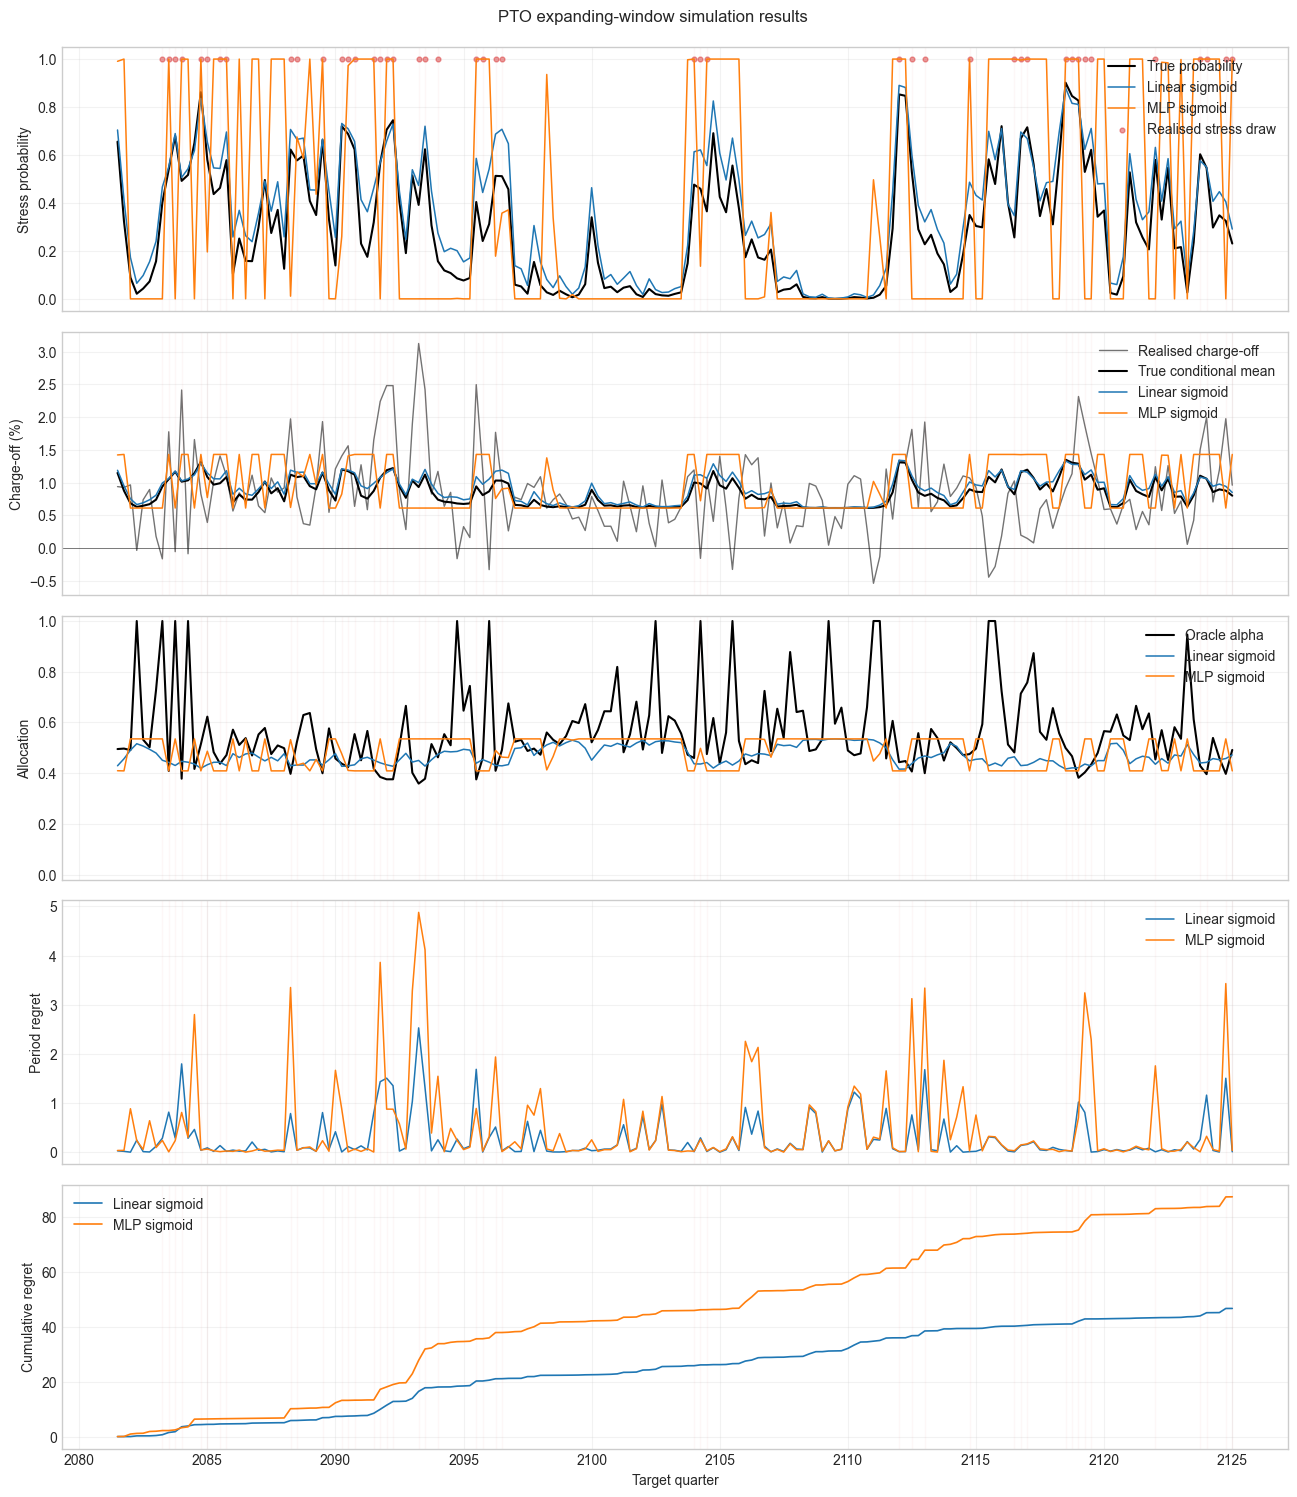

In [7]:
model_styles = {
    "pto_linear_sigmoid": {"color": "tab:blue", "label": "Linear sigmoid"},
    "pto_mlp_sigmoid": {"color": "tab:orange", "label": "MLP sigmoid"},
}
actual = results.drop_duplicates("time").sort_values("time")
stress_times = actual.loc[actual["stress_regime"].eq(1), "time"]

fig, axes = plt.subplots(5, 1, figsize=(13, 15), sharex=True)

axes[0].plot(actual["time"], actual["true_stress_probability"], color="black", linewidth=1.5, label="True probability")
for model_name, group in results.groupby("model"):
    style = model_styles[model_name]
    axes[0].plot(group["time"], group["predicted_stress_probability"], color=style["color"], linewidth=1.1, label=style["label"])
axes[0].scatter(stress_times, np.ones(len(stress_times)), color="tab:red", s=12, alpha=0.45, label="Realised stress draw")
axes[0].set_ylabel("Stress probability")
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(loc="upper right")

axes[1].plot(actual["time"], 100 * actual["realised_charge_off_rate"], color="0.45", linewidth=1.0, label="Realised charge-off")
axes[1].plot(actual["time"], 100 * actual["true_conditional_mean_charge_off"], color="black", linewidth=1.5, label="True conditional mean")
for model_name, group in results.groupby("model"):
    style = model_styles[model_name]
    axes[1].plot(group["time"], 100 * group["predicted_mean_charge_off"], color=style["color"], linewidth=1.1, label=style["label"])
axes[1].axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
axes[1].set_ylabel("Charge-off (%)")
axes[1].legend(loc="upper right")

axes[2].plot(actual["time"], actual["oracle_alpha"], color="black", linewidth=1.5, label="Oracle alpha")
for model_name, group in results.groupby("model"):
    style = model_styles[model_name]
    axes[2].plot(group["time"], group["predicted_alpha"], color=style["color"], linewidth=1.1, label=style["label"])
axes[2].set_ylabel("Allocation")
axes[2].set_ylim(-0.02, 1.02)
axes[2].legend(loc="upper right")

for model_name, group in results.groupby("model"):
    style = model_styles[model_name]
    axes[3].plot(group["time"], group["regret"], color=style["color"], linewidth=1.1, label=style["label"])
axes[3].set_ylabel("Period regret")
axes[3].legend(loc="upper right")

for model_name, group in results.groupby("model"):
    style = model_styles[model_name]
    axes[4].plot(group["time"], group["cumulative_regret"], color=style["color"], linewidth=1.2, label=style["label"])
axes[4].set_ylabel("Cumulative regret")
axes[4].set_xlabel("Target quarter")
axes[4].legend(loc="upper left")

for ax in axes:
    for stress_time in stress_times:
        ax.axvline(stress_time, color="tab:red", alpha=0.035, linewidth=1.0)
    ax.grid(True, alpha=0.25)

fig.suptitle("PTO expanding-window simulation results", y=0.995)
fig.tight_layout()
plt.show()


## 8. Save results

The saved dataframe is a clean expanding-window result panel with one row per model and test-period observation.


In [8]:
results_dir = REPO_ROOT / "models" / "simulation" / "results"
results_dir.mkdir(parents=True, exist_ok=True)

results_csv = results_dir / "pto_simulation_results.csv"
results.to_csv(results_csv, index=False)

print(f"Saved PTO simulation results to: {results_csv.relative_to(REPO_ROOT)}")
display(results.head())


Saved PTO simulation results to: models/simulation/results/pto_simulation_results.csv


,feature_time,time,model,train_size,true_stress_probability,predicted_stress_probability,stress_regime,true_conditional_mean_charge_off,predicted_mean_charge_off,realised_charge_off_rate,predicted_alpha,oracle_alpha,predicted_realised_utility,oracle_utility,regret,cumulative_regret
0,2081-04-01,2081-07-01,pto_linear_sigmoid,325,0.655478,0.704290,0,0.011475,0.011875,0.009375,0.429251,0.495212,1.174381,1.201178,0.026796,0.026796
1,2081-04-01,2081-07-01,pto_mlp_sigmoid,325,0.655478,0.990639,0,0.011475,0.014223,0.009375,0.409700,0.495212,1.166439,1.201178,0.034739,0.034739
2,2081-07-01,2081-10-01,pto_linear_sigmoid,326,0.323607,0.413004,0,0.008754,0.009487,0.009262,0.456856,0.497051,1.186114,1.202488,0.016375,0.043171
3,2081-07-01,2081-10-01,pto_mlp_sigmoid,326,0.323607,0.999999,0,0.008754,0.014300,0.009262,0.409154,0.497051,1.166681,1.202488,0.035808,0.070546
4,2081-10-01,2082-01-01,pto_linear_sigmoid,327,0.089071,0.172389,0,0.006830,0.007514,0.009641,0.490778,0.490997,1.198071,1.198160,0.000089,0.043259
